# Figure 3: Chromatin and Gene Expression

**Goal:**

Show the relationship of the chromatin and gene expression with respect to cell phases. What patterns are different per cell phase?

**Procedure:**
1. Partition out the genes by where there maximal expression lies (criteria: expression is 1.5 greater in the phase than any other phase). Quantify this.
2. Then, plot the 90/10 PTR ratio for the chromatin for each of these highly expressed genes
3. Are there any discernible patterns in the chromatin for each cell phase?


In [1]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
from src.Figure3_Chrom_Gene_Expression import Figure3_Chrom_GeneExpression

outdir = 'output/deconvolve_sharedg1_g0066_11x11_2024_07_23/'

figures = Figure3_Chrom_GeneExpression(outdir)

In [83]:
from src.config import load_configs_by_config_type

config1, config2 = load_configs_by_config_type('shared')
gene_expression = figures.gene_expression_a.gene_expression_f

In [92]:
t_indices = config1.get_Hpositions_for_branch('t')

In [284]:
from src.peak_to_trough import compute_quantile_ptr_2d

ret_ptr = compute_quantile_ptr_2d(gene_expression[t_indices], lo=0.1, hi=0.9)
ptr_df = pd.DataFrame(ret_ptr, index=gene_expression.index)
ptr_df.columns = ['ptr', 'lo_val_idx', 'hi_val_idx', 'f_lo', 'f_hi']
ptr_df.lo_val_idx = ptr_df.lo_val_idx.astype(int)
ptr_df.hi_val_idx = ptr_df.hi_val_idx.astype(int)
ptr_df = ptr_df.join(figures.genes[['gene_index']])

In [351]:
def get_partition_labels(n, n_partitions = 5):
    """Get the partition labels for a dataframe of size n"""
    
    step = n / n_partitions
    partition_labels = np.zeros(n)

    for i in range(n_partitions):
        start = int(i*step)
        end = int((i+1)*step) if i < n_partitions-1 else n
        partition_labels[start:end] = i
    
    return partition_labels


In [452]:
from src.global_config import GlobalConstants
from src.timer import Timer

def retrieve_peak_trough_ptr_imgs(current_orfs):
    def retrieve_peak_trough_imgs(orf_name):
        """Retrieve the peak and trough images for an orf"""
        from glob import glob
        f_mat_path = glob(f'{figures.outdir}chromatin/*_f_*{orf_name}*')[0]
        f_mat = np.load(f_mat_path)
        f_img = f_mat.reshape((-1, *GlobalConstants.IMAGE_SHAPE))
        ptr_row = ptr_df.loc[orf_name]
        lo_idx, hi_idx = int(ptr_row.lo_val_idx), int(ptr_row.hi_val_idx)
        lo_img = f_img[lo_idx]
        hi_img = f_img[hi_idx]
        return lo_img, hi_img

    timer = Timer()

    peak_cumulative_image = np.zeros(GlobalConstants.IMAGE_SHAPE)
    trough_cumulative_image = np.zeros(GlobalConstants.IMAGE_SHAPE)
    k = len(current_orfs)
    for i in range(k):
        orf_name = current_orfs[i]
        lo_img, hi_img = retrieve_peak_trough_imgs(orf_name)
        gene = figures.genes.loc[orf_name]

        if gene.strand == '-':
            lo_img = np.flip(lo_img, axis=1)
            hi_img = np.flip(hi_img, axis=1)

        # todo: normalize these images prior to accumulation...
        # don't fully understand the source of variation.
        # Could be a bug in copy number correction/normalisation or 
        # something unaccounted for
        TARGET_COUNT = 1000
        hi_img = hi_img / hi_img.sum() * TARGET_COUNT
        lo_img = lo_img / lo_img.sum() * TARGET_COUNT
            
        peak_cumulative_image += hi_img
        trough_cumulative_image += lo_img

        if i % 200 == 0: 
            timer.print_time(f"{i}/{k}")

    selected_indices = figures.genes.loc[current_orfs].gene_index.values
    ptr_cumulative_image = figures.ptr_imgs_strand_corrected[selected_indices].mean(axis=0)

    return peak_cumulative_image/k, trough_cumulative_image/k, \
        ptr_cumulative_image, (peak_cumulative_image-trough_cumulative_image)/k


In [456]:
n_partitions = 5
ptr_df_partitioned = ptr_df.sort_values('f_hi', ascending=False).copy()
ptr_df_partitioned['partitions'] = get_partition_labels(
    len(ptr_df_partitioned), n_partitions).astype(int)

partition_img_sets = []
for partition_num in range(n_partitions):
    partitioned_set_df = ptr_partitioned_df[ptr_partitioned_df.partition == partition_num]
    current_orfs = partitioned_set_df.index

    print(f"Retrieving images for partition: {partition_num}")
    peak_cumulative_image, trough_cumulative_image, ptr_cumulative_image, \
        difference_image =  retrieve_peak_trough_ptr_imgs(current_orfs)
    partition_img_sets.append((peak_cumulative_image, 
        trough_cumulative_image, ptr_cumulative_image, difference_image))

Retrieving images for partition: 0
0/1115 - 00:00:00.033
200/1115 - 00:00:06.240
400/1115 - 00:00:12.338
600/1115 - 00:00:18.407
800/1115 - 00:00:24.571
1000/1115 - 00:00:30.756
Retrieving images for partition: 1
0/1116 - 00:00:00.031
200/1116 - 00:00:06.090
400/1116 - 00:00:12.117
600/1116 - 00:00:18.411
800/1116 - 00:00:24.710
1000/1116 - 00:00:31.031
Retrieving images for partition: 2
0/1115 - 00:00:00.032
200/1115 - 00:00:06.316
400/1115 - 00:00:12.631
600/1115 - 00:00:19.001
800/1115 - 00:00:25.326
1000/1115 - 00:00:31.547
Retrieving images for partition: 3
0/1116 - 00:00:00.031
200/1116 - 00:00:06.491
400/1116 - 00:00:12.995
600/1116 - 00:00:19.425
800/1116 - 00:00:26.182
1000/1116 - 00:00:32.670
Retrieving images for partition: 4
0/1116 - 00:00:00.034
200/1116 - 00:00:06.423
400/1116 - 00:00:12.807
600/1116 - 00:00:19.010
800/1116 - 00:00:25.074
1000/1116 - 00:00:31.235


0

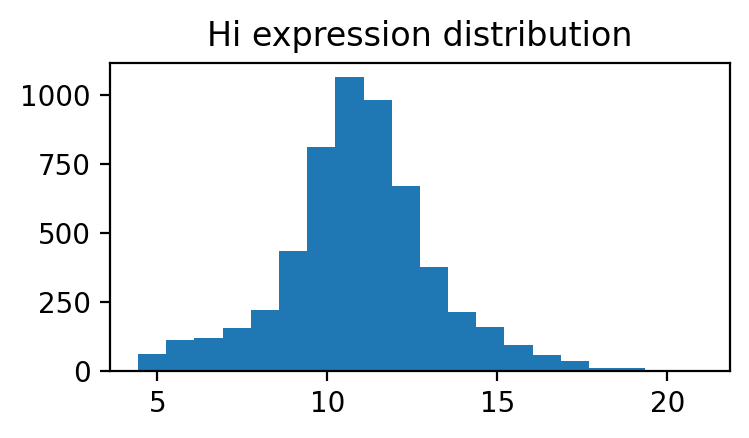

In [369]:
plt.figure(figsize=(4, 2))
plt.hist(ptr_df.f_hi, bins=20)
plt.title("Hi expression distribution")
0

In [457]:
from src.figure_configs import FiguresConfig

def plot_partition_set(partition_img_sets, title):
    plt.figure(figsize=(13, 10))
        
    for i in range(len(partition_img_sets)):
        peak_cumulative_image, trough_cumulative_image, ptr_cumulative_image,\
            difference_cumulative_image = partition_img_sets[i]

        plt.subplot(5, 3, (i*3)+1)
        def plot_img(img):
            plt.imshow(img, aspect='auto', cmap='magma_r', origin='lower')
            plt.xticks([])
            plt.yticks([])
            plt.axvline(img.shape[1]//2, c='black', alpha=0.1, lw=2)
        plot_img(peak_cumulative_image)
        plt.ylabel(f"Quantile {i+1}")
        if i == 0: plt.title("Peak")

        plt.subplot(5, 3, (i*3)+2)
        plot_img(trough_cumulative_image)
        if i == 0: plt.title("Trough")
        
        plt.subplot(5, 3, (i*3)+3)
        plt.imshow(difference_cumulative_image, aspect='auto',
                  origin='lower', cmap='RdBu_r', vmin=-1, vmax=1)
        plt.xticks([])
        plt.yticks([])
        plt.axvline(peak_cumulative_image.shape[1]//2, c='black', alpha=0.1, lw=2)
        if i == 0: plt.title("Difference: Peak-Trough")

        plt.suptitle(title, fontsize=FiguresConfig.FIG_SUPTITLE_FONTSIZE)
        plt.subplots_adjust(top=0.9, hspace=0.3, wspace=0.2)


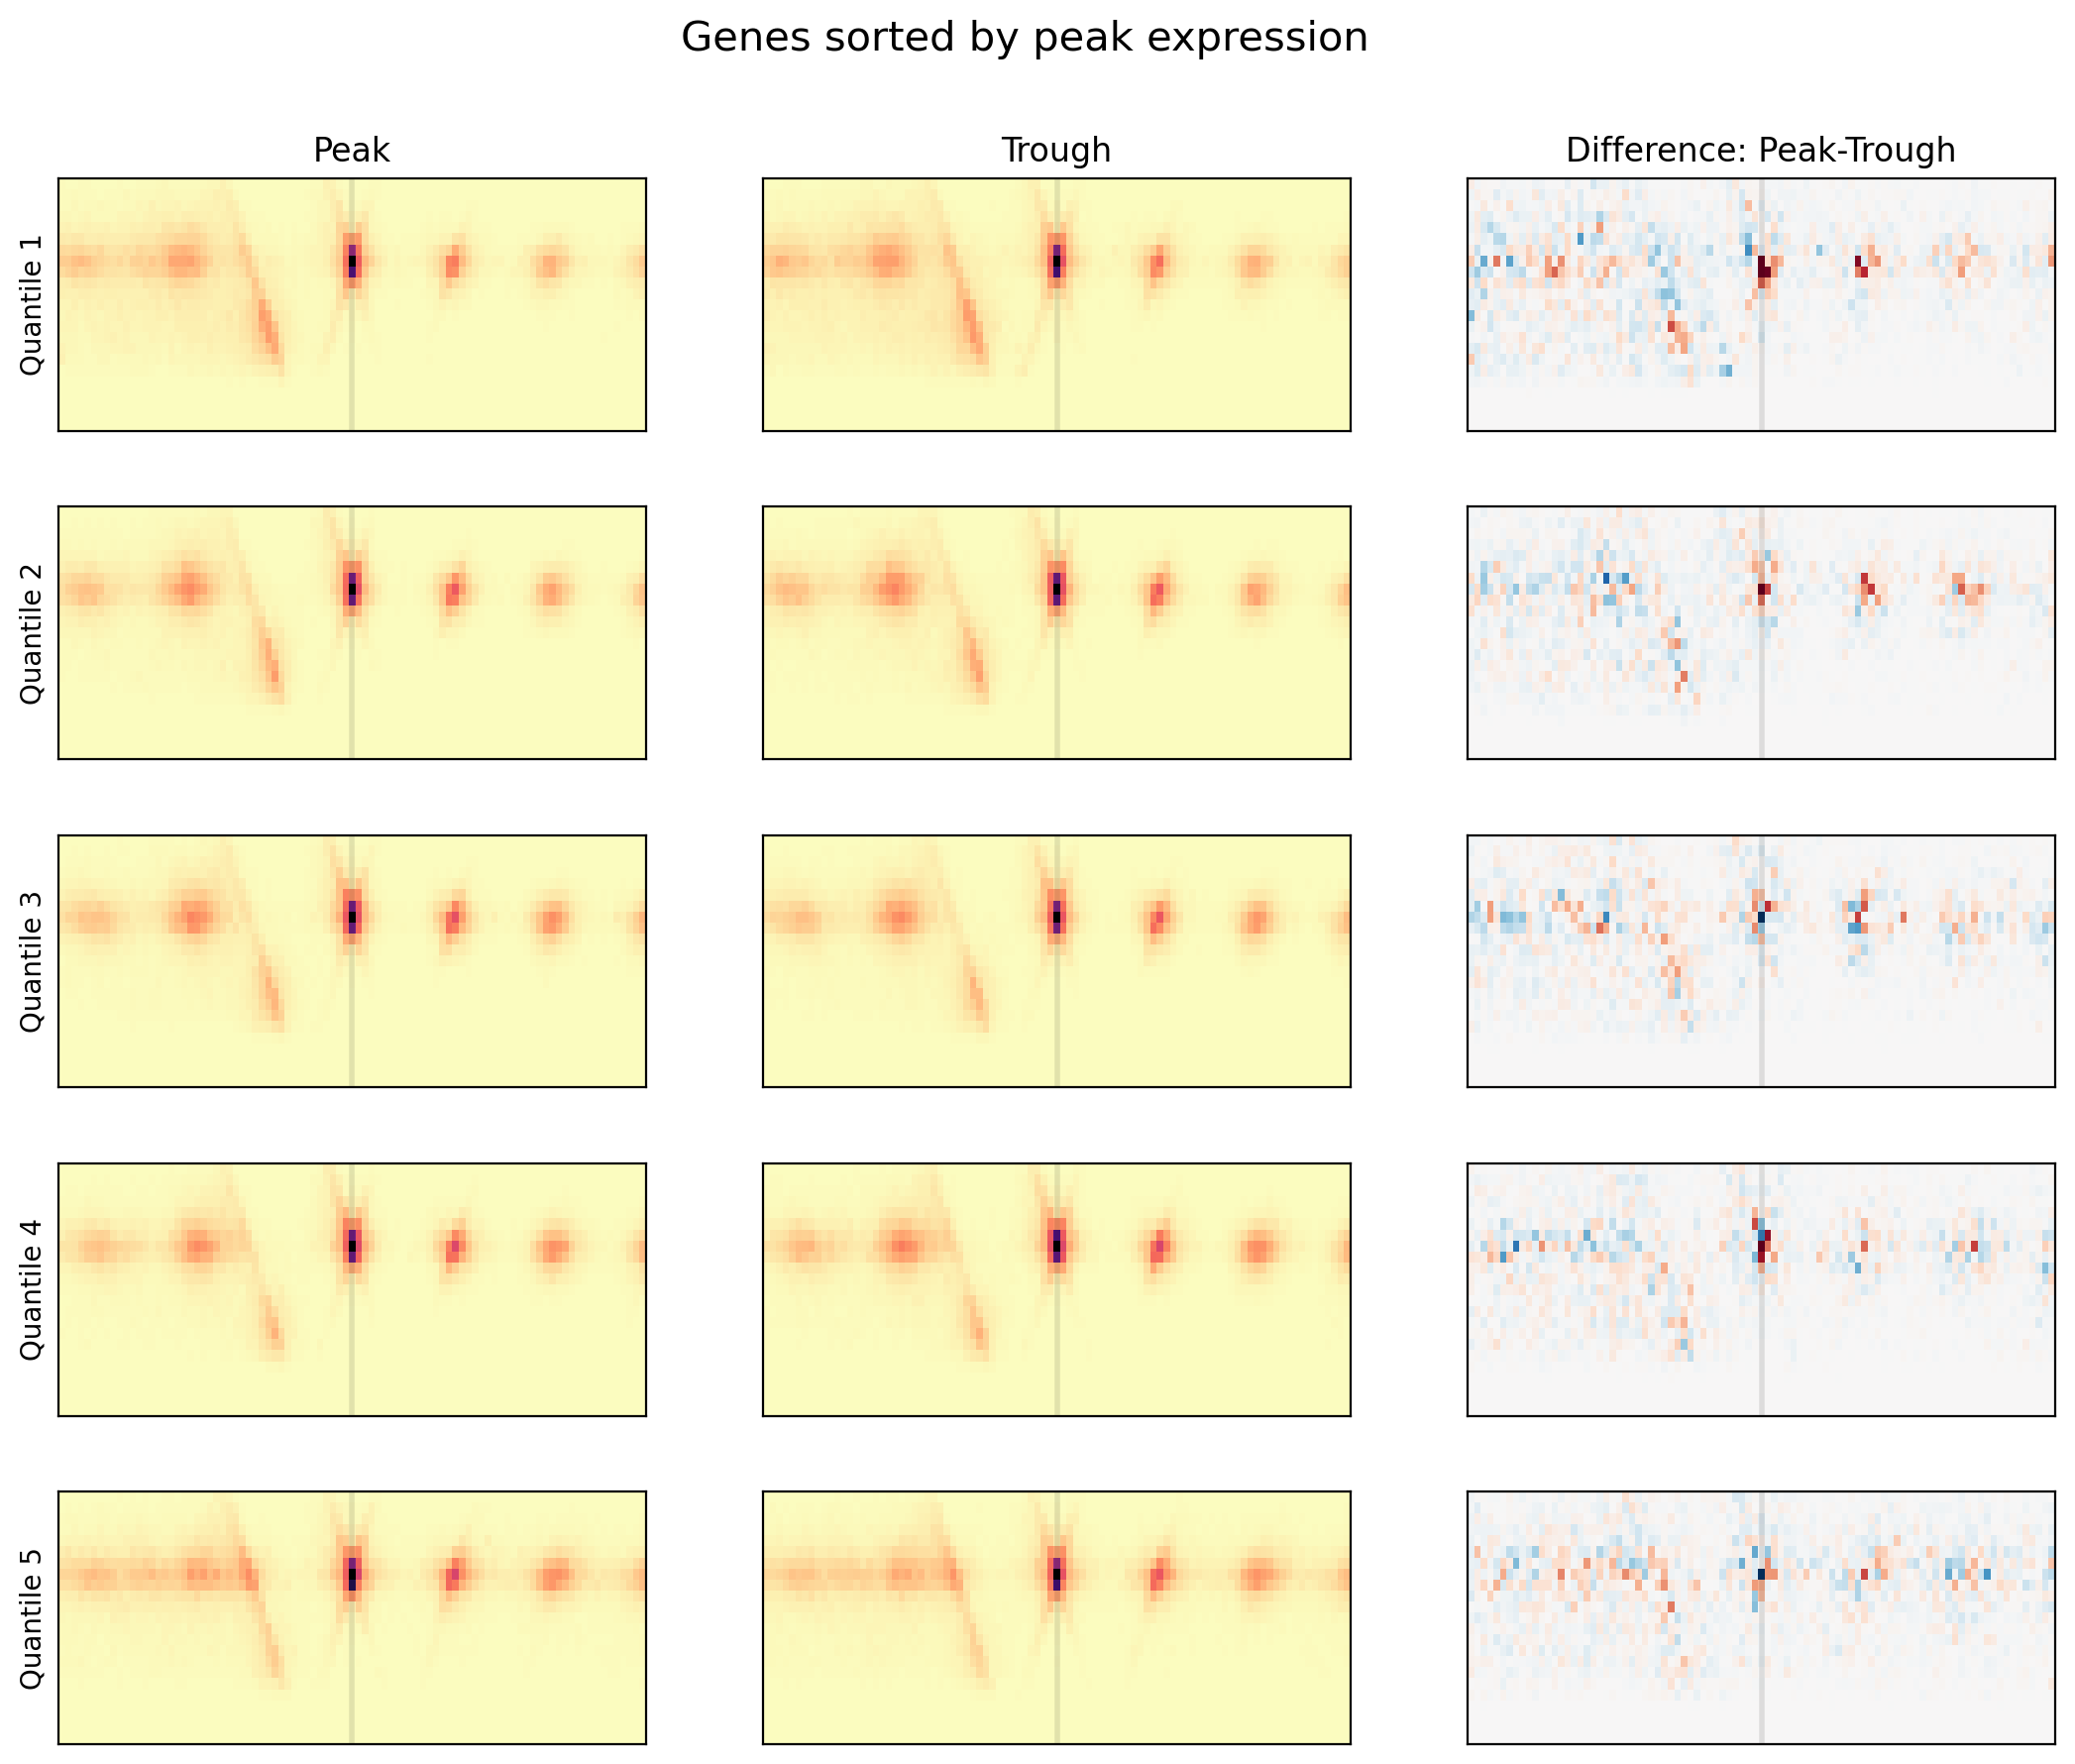

In [467]:
from src.figure_configs import FiguresConfig, save_figure_for_paper

plot_partition_set(partition_img_sets, f"Genes sorted by peak expression")
save_figure_for_paper("output/figures/Expression_Chromatin/Chromatin_PT_by_Expression.png")


In [440]:
# Get the highest transcription quintile, and sort by PTR
hi_tx_sorted_ptr = ptr_partitioned_df[ptr_partitioned_df.partition == 0]\
    .sort_values('ptr', ascending=False)

In [463]:
n_partitions = 4
hi_tx_ptr_partitions = hi_tx_sorted_ptr.copy()
hi_tx_ptr_partitions['ptr_partitions'] = get_partition_labels(
    len(hi_tx_sorted_ptr), n_partitions).astype(int)


In [464]:
hi_tx_partition_img_sets = []
for partition_num in range(n_partitions):
    partitioned_set_df = hi_tx_ptr_partitions[hi_tx_ptr_partitions.ptr_partitions 
        == partition_num]
    current_orfs = partitioned_set_df.index

    print(f"Retrieving images for partition: {partition_num}")
    peak_cumulative_image, trough_cumulative_image, ptr_cumulative_image, \
        difference_cumulative_image = retrieve_peak_trough_ptr_imgs(current_orfs)
    hi_tx_partition_img_sets.append((peak_cumulative_image, 
        trough_cumulative_image, ptr_cumulative_image, difference_cumulative_image))


Retrieving images for partition: 0
0/278 - 00:00:00.109
200/278 - 00:00:06.457
Retrieving images for partition: 1
0/279 - 00:00:00.032
200/279 - 00:00:06.402
Retrieving images for partition: 2
0/279 - 00:00:00.032
200/279 - 00:00:06.297
Retrieving images for partition: 3
0/279 - 00:00:00.031
200/279 - 00:00:06.879


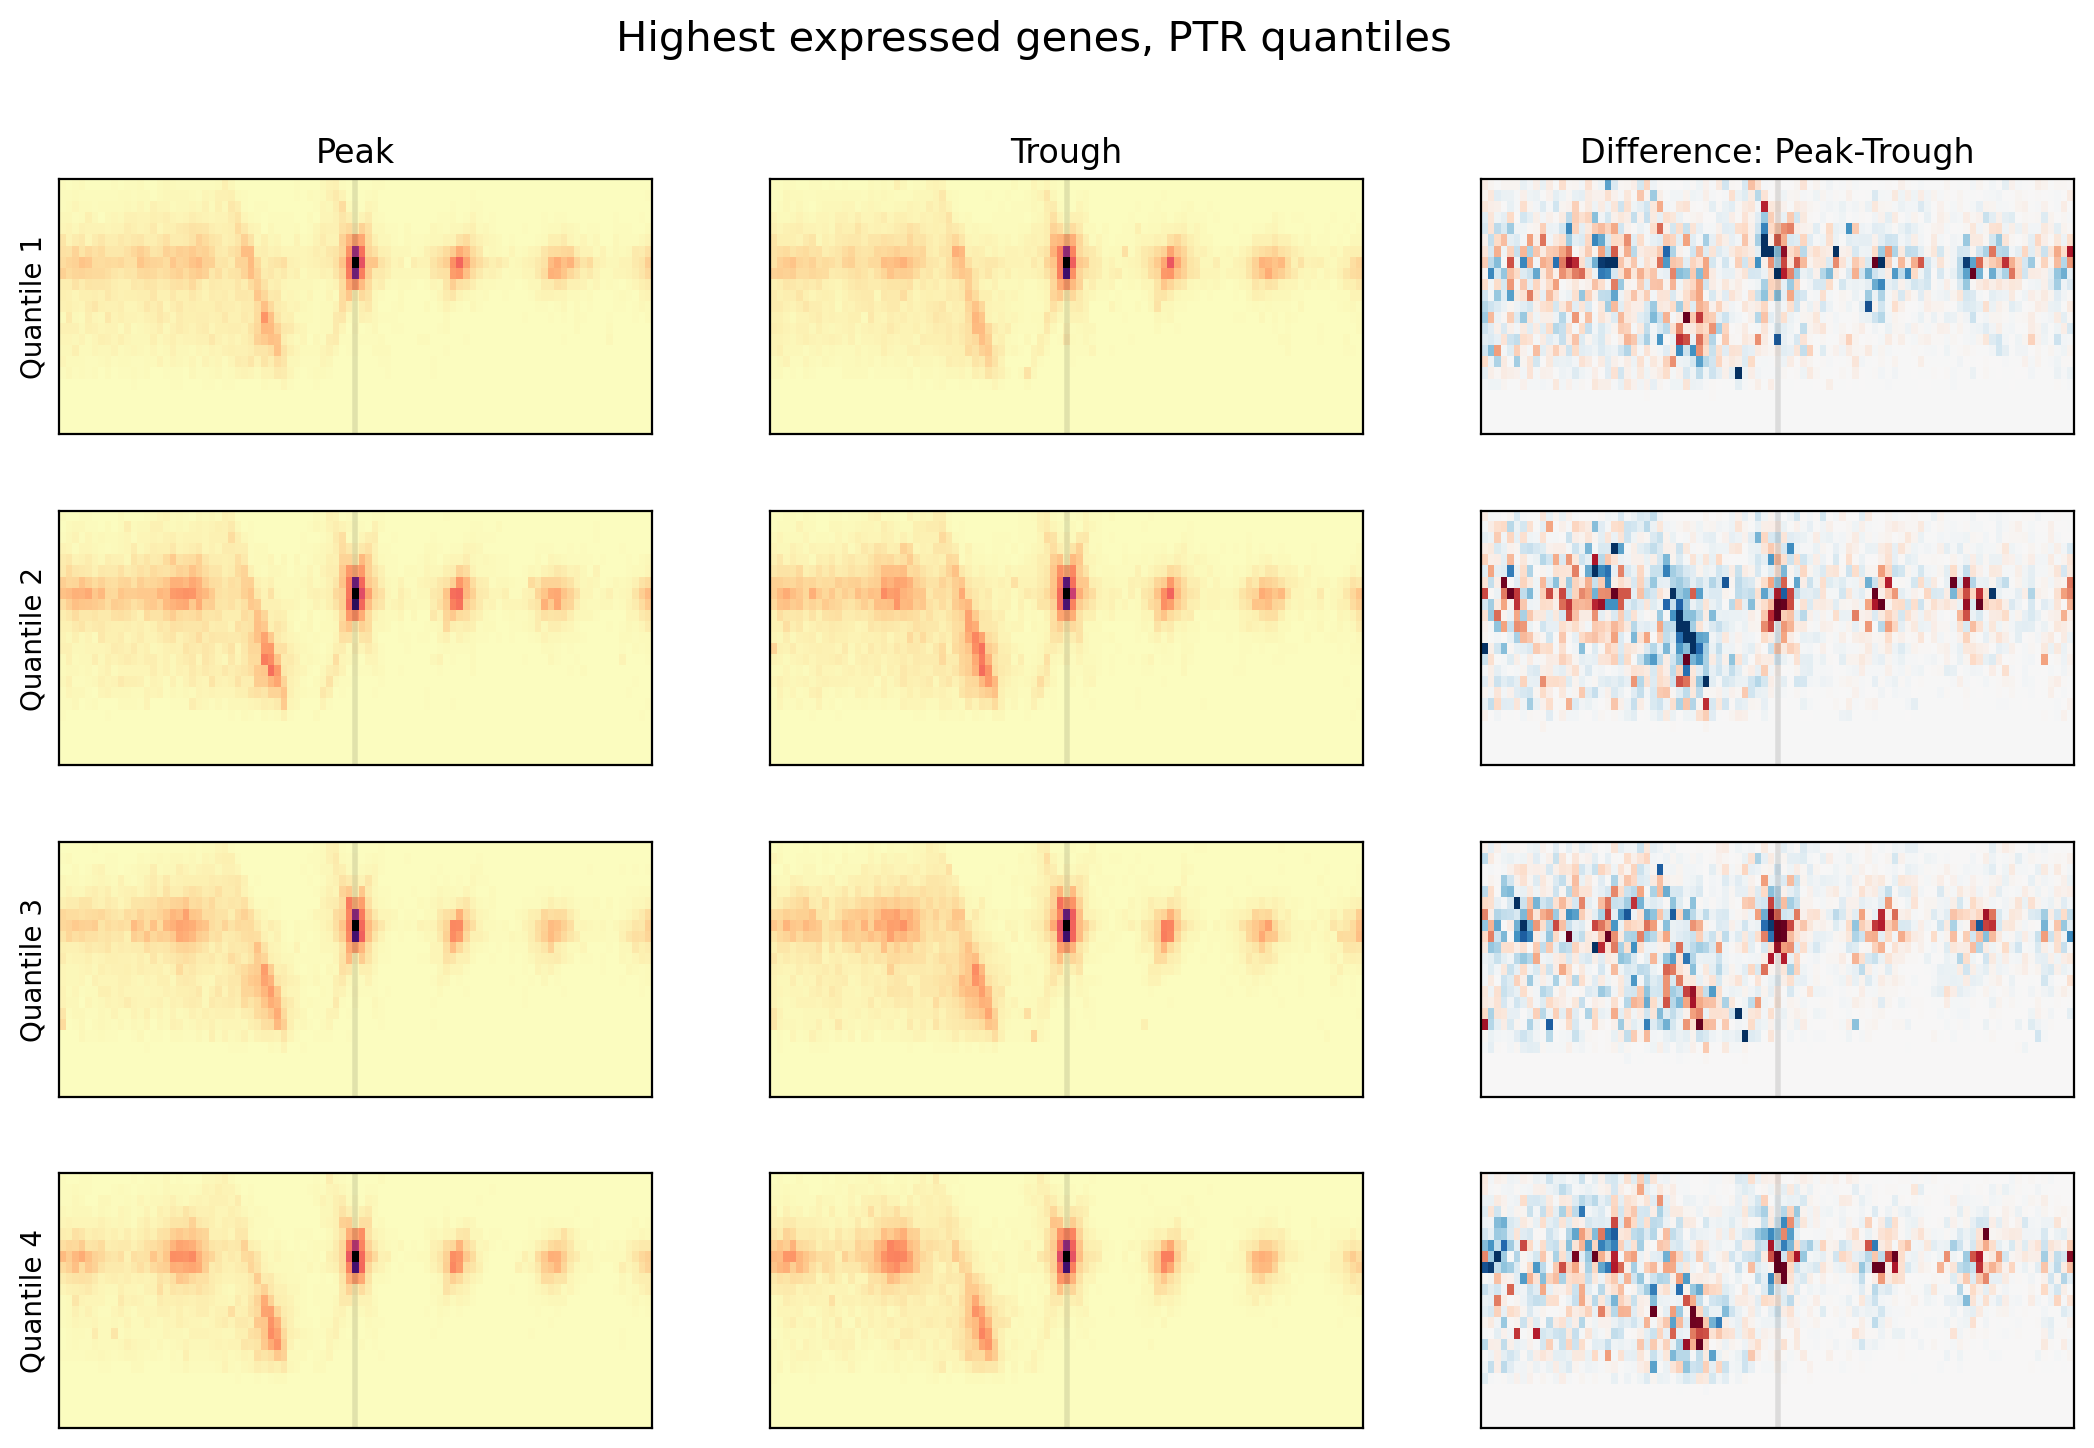

In [468]:
plot_partition_set(hi_tx_partition_img_sets, "Highest expressed genes, PTR quantiles")
save_figure_for_paper("output/figures/Expression_Chromatin/High_Expression_Chromatin_PT_by_Expression.png")